# 05 — GA Optimizer · LineWise (week 18-22 May 2026)

**Goal.** For the specific test week **18-22 May 2026**, find the assignment
(*which line produces each SKU*) and sequencing (*chronological order inside
each line*) that **minimises total weekly hours** = production + changeovers,
across L14, L17 and L19. By mentor mandate this is mathematically equivalent
to maximising plant OEE. Every leftover hour over the baseline plan is real
spare capacity recovered, especially on the L19 bottleneck.

**Differences vs v1.**
- No regression / embedding simulator. We use **real historical lookups**:
  median throughput per `(SKU, line)` from the 2025 dataset, and a real
  changeover matrix per line built by `PostMortemAnalysis.build_transition_matrices()`.
- **Dict-of-lists chromosome**: `{'14': [...], '17': [...], '19': [...]}`.
  Every weekly SKU appears exactly once across the three lists.
- **Smart init**: every individual in generation 0 is physically feasible.
- **Two-strategy mutation**: intra-line swap to improve changeovers + inter-line
  migration to off-load L19.
- **Baseline = the planner's diary order** evaluated with the same simulator,
  so the saved-hours number is apples-to-apples.


## 1 · Imports & mentor constants

In [47]:
from __future__ import annotations

import json, random, sys
from copy import deepcopy
from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

HOURS_PER_WEEK: Dict[str, float] = {"14": 110.0, "17": 115.0, "19": 115.0}
LINES: List[str] = ["14", "17", "19"]

# Format codes: "1/2" = 50cl, "1/3" = 33cl, "2/5" = 44cl.
PHYSICAL_FORMAT_BY_LINE: Dict[str, set[str]] = {
    "14": {"1/2", "1/3"},
    "17": {"1/3"},
    "19": {"1/2", "1/3", "2/5"},
}

# Contractually urgent orders: (SKU, line). Must land in the first 25 % of the
# line's chronological sequence.
PRIORITY_ORDERS: List[Tuple[str, str]] = [("VI1324MY", "17")]

# Tabla CF arranque por línea (horas).
STARTUP_HOURS: Dict[str, float] = {"14": 1.0, "17": 1.5, "19": 1.5}

# Penalty weights (in synthetic "penalty hours") — large enough to dominate the
# fitness when constraints are violated, finite so the GA still has gradient.
PENALTY_INCOMPATIBLE = 10_000.0
PENALTY_CAPACITY_BASE = 100.0   # exponential ramp on overshoot
PENALTY_PRIORITY = 500.0

POP_SIZE = 60
N_GEN = 150
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("/Users/josecalatayud/DAMMxEHub/DAMMxUHub/OPERACIONS")
sys.path.insert(0, str(DATA_DIR.parent / "analisis_postmorten"))


## 2 · Load 2025 history + the May 18-22 weekly plan

Two sources of truth:
- `OEE / Cambios / Tiempo / Volumen 14_17_19_2025.xlsx` → throughput &
  transition history.
- `Diario Hl_Planif.xlsx` → the SKUs and HL demand for the week we are
  optimising. The diary's line order is the **baseline plan** we will beat.


In [48]:
from data_loaders import load_all_operations, load_diario_hl, weekly_demand_from_diario

ops = load_all_operations(DATA_DIR)
df_oee, df_cam, df_mant, df_tiem, df_vol = (
    ops["oee"], ops["cam"], ops["mant"], ops["tiem"], ops["vol"]
)

df_diario = load_diario_hl(DATA_DIR / "Diario Hl_Planif.xlsx")
weekly = weekly_demand_from_diario(df_diario)
weekly["original_line"] = weekly["original_tren"].str.split(",").str[0]

print(f"Week-18-22 SKUs to schedule: {len(weekly)}")
print(f"Total weekly demand: {weekly['hl_total'].sum():,.0f} HL")
weekly[["sku", "original_line", "original_tren", "hl_total"]].head(10)


Week-18-22 SKUs to schedule: 28
Total weekly demand: 36,933 HL


,sku,original_line,original_tren,hl_total
0,ED13LP24,14,"14,17",5591.519958
1,FDT13LT,14,14,1671.120026
2,VO13LTNN,14,14,574.200012
3,DL13LT,17,17,3117.870117
4,FD13LTNN,17,17,1393.919983
5,FDL13LN,17,17,720.719971
6,KE13LTNN,17,17,625.680008
7,KE13PL12,17,17,293.040009
8,LC13LTNN,17,17,1789.919922
9,SK13LN,17,17,1927.170044


## 3 · Build the historical changeover matrix per line

We reuse `PostMortemAnalysis.build_transition_matrices()` which already
reconstructs the 2025 chronological sequences and aggregates real
`(sku_prev → sku, line)` durations from the Cambios file.


In [49]:
from post_mortem import PostMortemAnalyzer

pm = PostMortemAnalyzer(df_oee=df_oee, df_cambios=df_cam,
                         df_mantenimiento=df_mant, df_tiempo=df_tiem,
                         df_volumen=df_vol)
pm.clean_and_isolate_maintenance()
transitions = pm.build_transition_matrices()

# Real changeover lookup: CHANGEOVER[line][(prev_sku, next_sku)] -> hours.
# Fallback per line = mean of observed changeovers on that line.
CHANGEOVER: Dict[str, Dict[Tuple[str, str], float]] = {}
LINE_MEAN_CO: Dict[str, float] = {}

for line in LINES:
    mat = transitions.get(line, {}).get("changeover_h")
    line_map: Dict[Tuple[str, str], float] = {}
    if mat is not None and not mat.empty:
        stacked = mat.stack(dropna=True)
        for (prev, nxt), hours in stacked.items():
            if pd.notna(hours):
                line_map[(prev, nxt)] = float(hours) / 60.0 if hours > 30 else float(hours)
    CHANGEOVER[line] = line_map
    LINE_MEAN_CO[line] = (np.mean(list(line_map.values())) if line_map else 1.0)
    print(f"L{line}: {len(line_map):,} historical transitions · mean = {LINE_MEAN_CO[line]:.2f}h")


[clean_and_isolate_maintenance] OFs contaminadas (>20%): 293/2141 (13.7%)
  → imputadas por mediana SKU-línea (>50%): 105
[build_transition_matrices] Línea 14: 259 transiciones únicas (63 SKUs origen, 63 SKUs destino)
[build_transition_matrices] Línea 17: 517 transiciones únicas (76 SKUs origen, 75 SKUs destino)
[build_transition_matrices] Línea 19: 547 transiciones únicas (108 SKUs origen, 108 SKUs destino)
L14: 148 historical transitions · mean = 2.01h
L17: 388 historical transitions · mean = 1.51h
L19: 402 historical transitions · mean = 1.48h


## 4 · Throughput lookup (median HL/h per SKU × line)

Median is more robust than mean to one-off bad shifts. We require ≥ 1 real OF
per `(sku, line)` pair; missing pairs fall back to the SKU's plant-wide median.


In [50]:
hl_per_h = (df_vol.merge(df_tiem[["of", "h_tot"]], on="of", how="left")
                     .dropna(subset=["sku", "tren", "hl", "h_tot"]))
hl_per_h = hl_per_h[hl_per_h["h_tot"] > 0]
hl_per_h["rate"] = hl_per_h["hl"] / hl_per_h["h_tot"]
hl_per_h = hl_per_h[hl_per_h["rate"].between(20, 800)]

THROUGHPUT: Dict[Tuple[str, str], float] = (
    hl_per_h.groupby(["sku", "tren"])["rate"].median().to_dict()
)
SKU_GLOBAL_RATE: Dict[str, float] = (
    hl_per_h.groupby("sku")["rate"].median().to_dict()
)
PLANT_MEAN_RATE = float(hl_per_h["rate"].median())


def throughput(sku: str, line: str) -> float:
    rate = THROUGHPUT.get((sku, line))
    if rate is None or not np.isfinite(rate):
        rate = SKU_GLOBAL_RATE.get(sku, PLANT_MEAN_RATE)
    return float(max(20.0, rate))


print(f"Throughput pairs: {len(THROUGHPUT)} · plant median = {PLANT_MEAN_RATE:.0f} HL/h")


Throughput pairs: 251 · plant median = 143 HL/h


## 5 · SKU eligibility — mentor format rules ∩ 2025 history

A SKU may go on a line **iff** the line's `PHYSICAL_FORMAT_BY_LINE` allows the
SKU's format **and** 2025 recorded at least one OF of that SKU on that line.


In [51]:
import re

def parse_format(sku: str) -> str:
    s = str(sku).upper()
    m = re.search(r"(33|50|44)", s)
    cl = int(m.group(1)) if m else 33
    return {33: "1/3", 50: "1/2", 44: "2/5"}[cl]


SKU_FORMAT: Dict[str, str] = {sku: parse_format(sku) for sku in weekly["sku"]}

hist_pairs = set()
for df in (df_oee, df_vol, df_tiem):
    if "sku" in df.columns and "tren" in df.columns:
        for sku, tren in df[["sku", "tren"]].dropna().itertuples(index=False):
            hist_pairs.add((str(sku), str(tren)))


def eligible_lines(sku: str) -> List[str]:
    fmt = SKU_FORMAT.get(sku)
    out = [line for line in LINES
           if fmt in PHYSICAL_FORMAT_BY_LINE[line] and (sku, line) in hist_pairs]
    return out


ELIGIBLE: Dict[str, List[str]] = {}
fallback_used = []
for sku in weekly["sku"]:
    opts = eligible_lines(sku)
    if not opts:
        # No 2025 precedent → trust the planner's original line so the SKU is
        # still placeable. This protects new launches.
        original = weekly.loc[weekly["sku"] == sku, "original_line"].iloc[0]
        opts = [original]
        fallback_used.append(sku)
    ELIGIBLE[sku] = opts

SKUS: List[str] = weekly["sku"].tolist()
VOLUMES: Dict[str, float] = dict(zip(weekly["sku"], weekly["hl_total"]))

print(f"SKUs with multi-line flexibility: "
      f"{sum(1 for o in ELIGIBLE.values() if len(o) > 1)} / {len(ELIGIBLE)}")
print(f"SKUs using planner-fallback (no 2025 precedent): {len(fallback_used)}")


SKUs with multi-line flexibility: 15 / 28
SKUs using planner-fallback (no 2025 precedent): 0


## 6 · Realistic plant simulator (the fitness function)

`evaluate_schedule(individual) -> (total_hours,)` returns a single scalar so
this works unchanged with DEAP's minimisation if you wire it up.


In [52]:
Chromosome = Dict[str, List[str]]   # {line: [sku, ...]} ordered list


def changeover_hours(prev_sku: str, next_sku: str, line: str) -> float:
    if prev_sku == next_sku:
        return 0.0
    val = CHANGEOVER[line].get((prev_sku, next_sku))
    if val is None or not np.isfinite(val):
        # Symmetric fallback: maybe the reverse pair is observed.
        val = CHANGEOVER[line].get((next_sku, prev_sku))
    if val is None or not np.isfinite(val):
        # Last resort: the line's mean changeover, slightly higher when the
        # format changes (a real transition cost we don't want to under-count).
        base = LINE_MEAN_CO[line]
        if SKU_FORMAT.get(prev_sku) != SKU_FORMAT.get(next_sku):
            base *= 2.5
        val = base
    return float(max(0.0, min(12.0, val)))


def simulate_line(line: str, sequence: List[str]) -> Dict[str, float]:
    if not sequence:
        return {"total": 0.0, "prod": 0.0, "changeover": 0.0, "startup": 0.0}
    prod = sum(VOLUMES[s] / throughput(s, line) for s in sequence)
    co = sum(changeover_hours(sequence[i], sequence[i + 1], line)
             for i in range(len(sequence) - 1))
    startup = STARTUP_HOURS[line]
    return {"prod": prod, "changeover": co, "startup": startup,
            "total": prod + co + startup}


def evaluate_schedule(individual: Chromosome) -> Tuple[float]:
    """Return (fitness,) — total hours + penalties — to minimise."""
    total_hours = 0.0
    penalty = 0.0

    # Each SKU must appear exactly once.
    flat = [s for line in LINES for s in individual.get(line, [])]
    if len(flat) != len(SKUS) or set(flat) != set(SKUS):
        return (PENALTY_INCOMPATIBLE * 10,)

    for line in LINES:
        seq = individual.get(line, [])

        # Death penalty: format / historical incompatibility.
        for sku in seq:
            if SKU_FORMAT.get(sku) not in PHYSICAL_FORMAT_BY_LINE[line]:
                penalty += PENALTY_INCOMPATIBLE
            elif (sku, line) not in hist_pairs and sku not in fallback_used:
                penalty += PENALTY_INCOMPATIBLE / 2

        sim = simulate_line(line, seq)
        total_hours += sim["total"]

        # Exponential capacity penalty above the weekly cap.
        if sim["total"] > HOURS_PER_WEEK[line]:
            overshoot = sim["total"] - HOURS_PER_WEEK[line]
            penalty += PENALTY_CAPACITY_BASE * (np.exp(overshoot / 5.0) - 1.0)

        # Priority: urgent SKU in the first 25 % of its line's sequence.
        for urgent_sku, urgent_line in PRIORITY_ORDERS:
            if urgent_line == line and urgent_sku in seq:
                pos = seq.index(urgent_sku)
                cutoff = max(0, int(0.25 * len(seq)))
                if pos > cutoff:
                    penalty += PENALTY_PRIORITY * ((pos - cutoff) / max(1, len(seq)))

    return (total_hours + penalty,)


def breakdown(individual: Chromosome) -> Dict[str, Dict[str, float]]:
    return {line: simulate_line(line, individual.get(line, [])) for line in LINES}


## 7 · Smart initialisation & genetic operators

The whole point of "smart init" is that generation 0 contains **zero**
infeasible individuals — every SKU lands on a line from its `ELIGIBLE` set.
The GA then improves *order* and *load balance* from there.


In [53]:
def smart_init() -> Chromosome:
    ind: Chromosome = {line: [] for line in LINES}
    # Place urgent SKUs first on their mandated line so they stay near the head.
    placed = set()
    for sku, line in PRIORITY_ORDERS:
        if sku in SKUS and line in ELIGIBLE[sku]:
            ind[line].append(sku)
            placed.add(sku)
    for sku in SKUS:
        if sku in placed:
            continue
        line = random.choice(ELIGIBLE[sku])
        ind[line].append(sku)
    for line in LINES:
        body = ind[line]
        head = [s for s, l in PRIORITY_ORDERS if l == line and s in body]
        rest = [s for s in body if s not in head]
        random.shuffle(rest)
        ind[line] = head + rest
    return ind


def crossover(p1: Chromosome, p2: Chromosome) -> Chromosome:
    """Multi-list permutation crossover.

    Inherit half of one parent's line assignments; for any SKU not yet placed,
    take the other parent's assignment if it is eligible, else resample.
    Then for each line, take a contiguous order slice from p1 and fill the
    rest in p2's relative order (Order-Crossover spirit).
    """
    child: Chromosome = {line: [] for line in LINES}
    sku_to_line_p1 = {s: l for l in LINES for s in p1[l]}
    sku_to_line_p2 = {s: l for l in LINES for s in p2[l]}

    for sku in SKUS:
        a, b = sku_to_line_p1.get(sku), sku_to_line_p2.get(sku)
        chosen = a if random.random() < 0.5 else b
        if chosen not in ELIGIBLE[sku]:
            chosen = a if a in ELIGIBLE[sku] else (b if b in ELIGIBLE[sku]
                                                    else random.choice(ELIGIBLE[sku]))
        child[chosen].append(sku)

    # Order-crossover per line, using p1's order as the donor of a contiguous
    # segment and p2's order as the filler.
    for line in LINES:
        members = child[line]
        if len(members) <= 2:
            continue
        p1_order = [s for s in p1[line] if s in members]
        p2_order = [s for s in p2[line] if s in members]
        # ensure all members are seen in both orders
        for s in members:
            if s not in p1_order: p1_order.append(s)
            if s not in p2_order: p2_order.append(s)
        n = len(members)
        a, b = sorted(random.sample(range(n), 2))
        segment = p1_order[a:b + 1]
        rest = [s for s in p2_order if s not in segment]
        new_order = rest[:a] + segment + rest[a:]
        child[line] = new_order
    return child


def mutate_swap(ind: Chromosome) -> Chromosome:
    # Intra-line swap to improve local changeovers.
    candidates = [l for l in LINES if len(ind[l]) >= 2]
    if not candidates:
        return ind
    line = random.choice(candidates)
    seq = ind[line]
    i, j = random.sample(range(len(seq)), 2)
    seq[i], seq[j] = seq[j], seq[i]
    return ind


def mutate_migrate(ind: Chromosome) -> Chromosome:
    """Move a SKU from the most overloaded line to a compatible underloaded one."""
    bd = breakdown(ind)
    over = sorted(LINES,
                   key=lambda l: bd[l]["total"] - HOURS_PER_WEEK[l],
                   reverse=True)
    under = sorted(LINES,
                    key=lambda l: bd[l]["total"] - HOURS_PER_WEEK[l])
    src = over[0]
    if not ind[src]:
        return ind
    # Try each SKU on the overloaded line until we find one we can off-load.
    movable = [s for s in ind[src] if len(ELIGIBLE[s]) > 1]
    random.shuffle(movable)
    for sku in movable:
        candidates = [l for l in ELIGIBLE[sku] if l != src and l in under[:2]]
        if not candidates:
            candidates = [l for l in ELIGIBLE[sku] if l != src]
        if not candidates:
            continue
        dst = candidates[0]
        ind[src].remove(sku)
        # Insert at a random position in dst.
        pos = random.randint(0, len(ind[dst]))
        ind[dst].insert(pos, sku)
        return ind
    return ind


def mutate(ind: Chromosome) -> Chromosome:
    ind = deepcopy(ind)
    if random.random() < 0.5:
        return mutate_swap(ind)
    return mutate_migrate(ind)


def tournament(pop_with_fit, k: int = 3):
    cands = random.sample(pop_with_fit, k)
    return min(cands, key=lambda x: x[1])[0]


## 8 · Evolution loop

In [54]:
def evolve(pop_size: int = POP_SIZE, n_gen: int = N_GEN,
           elitism: int = 4, verbose_every: int = 15):
    population: List[Chromosome] = [smart_init() for _ in range(pop_size)]
    fitnesses = [evaluate_schedule(ind)[0] for ind in population]
    history = []
    best_ind = deepcopy(population[int(np.argmin(fitnesses))])
    best_fit = min(fitnesses)

    for gen in range(n_gen):
        pop_fit = sorted(zip(population, fitnesses), key=lambda x: x[1])
        new_pop = [deepcopy(ind) for ind, _ in pop_fit[:elitism]]
        while len(new_pop) < pop_size:
            p1 = tournament(pop_fit)
            p2 = tournament(pop_fit)
            child = crossover(p1, p2)
            if random.random() < 0.85:
                child = mutate(child)
            new_pop.append(child)
        population = new_pop
        fitnesses = [evaluate_schedule(ind)[0] for ind in population]
        gen_best = min(fitnesses)
        if gen_best < best_fit:
            best_fit = gen_best
            best_ind = deepcopy(population[int(np.argmin(fitnesses))])
        history.append({"gen": gen, "best": best_fit,
                         "median": float(np.median(fitnesses))})
        if gen % verbose_every == 0:
            print(f"  gen {gen:3d}  best = {best_fit:9.2f}  "
                  f"median = {history[-1]['median']:9.2f}")
    return best_ind, history


print(f"Running GA (pop={POP_SIZE}, ngen={N_GEN})…")
best_ind, history = evolve()
print(f"\nFinal best fitness (hours + penalties): {evaluate_schedule(best_ind)[0]:.2f}")


Running GA (pop=60, ngen=150)…
  gen   0  best =    279.64  median =   2396.91
  gen  15  best =    264.38  median =    272.64
  gen  30  best =    261.61  median =    271.44
  gen  45  best =    259.70  median =    265.49
  gen  60  best =    259.70  median =    268.79
  gen  75  best =    259.70  median =    263.28
  gen  90  best =    259.70  median =    267.16
  gen 105  best =    259.70  median =    264.88
  gen 120  best =    259.52  median =    265.50
  gen 135  best =    259.52  median =    264.46

Final best fitness (hours + penalties): 259.52


## 9 · Baseline (diary plan) vs optimized — ROI dashboard

> **Concepto clave del "baseline".**
> El **baseline** son las horas totales que requiere **la planificación que
> hizo el planner** (orden y asignación tal como están en
> `Diario Hl_Planif.xlsx`), evaluada con nuestro simulador. **No** es la
> capacidad máxima de la línea. La capacidad (110 / 115 / 115 h) es el techo
> contractual que la planificación no debe superar.
>
> Lo que reportamos como "ahorrado" = `baseline − optimizado`. Esas son horas
> reales que el GA libera *dentro del mismo plan*: producir lo mismo en menos
> tiempo gracias a mejor asignación a línea + mejor orden interno.


In [55]:
def baseline_individual() -> Chromosome:
    ind: Chromosome = {line: [] for line in LINES}
    for _, row in weekly.sort_values(["first_fecha", "row_order"]).iterrows():
        ind[row.original_line].append(row.sku)
    return ind


base_ind = baseline_individual()
base_bd = breakdown(base_ind)
opt_bd = breakdown(best_ind)

rows = []
for line in LINES:
    cap = HOURS_PER_WEEK[line]
    b, o = base_bd[line], opt_bd[line]
    rows.append({
        "Line": f"L{line}",
        "Cap (h)": cap,
        "Baseline total (h)": round(b["total"], 1),
        "Baseline CO (h)": round(b["changeover"], 1),
        "Baseline slack (h)": round(cap - b["total"], 1),
        "Optimized total (h)": round(o["total"], 1),
        "Optimized CO (h)": round(o["changeover"], 1),
        "Optimized slack (h)": round(cap - o["total"], 1),
        "Saved (h)": round(b["total"] - o["total"], 1),
    })
total_b = sum(base_bd[l]["total"] for l in LINES)
total_o = sum(opt_bd[l]["total"] for l in LINES)
rows.append({
    "Line": "TOTAL",
    "Cap (h)": sum(HOURS_PER_WEEK.values()),
    "Baseline total (h)": round(total_b, 1),
    "Baseline CO (h)": round(sum(base_bd[l]["changeover"] for l in LINES), 1),
    "Baseline slack (h)": round(sum(HOURS_PER_WEEK.values()) - total_b, 1),
    "Optimized total (h)": round(total_o, 1),
    "Optimized CO (h)": round(sum(opt_bd[l]["changeover"] for l in LINES), 1),
    "Optimized slack (h)": round(sum(HOURS_PER_WEEK.values()) - total_o, 1),
    "Saved (h)": round(total_b - total_o, 1),
})
roi = pd.DataFrame(rows)

print("\n=== WEEKLY CAPACITY ROI · 18-22 May 2026 ===")
print(roi.to_string(index=False))
print(f"\n>>> Net weekly hours saved: {total_b - total_o:+.1f} h "
      f"({(total_b - total_o) / total_b * 100:+.1f}% of baseline total)")
print(f">>> L19 status: baseline = {base_bd['19']['total']:.1f}h / 115h "
      f"→ optimized = {opt_bd['19']['total']:.1f}h / 115h")

# Priority compliance
print("\n>>> Priority order placement:")
for sku, line in PRIORITY_ORDERS:
    if sku not in SKUS:
        print(f"   [N/A]  {sku} not in this week's demand — priority rule inactive")
        continue
    if sku in best_ind[line]:
        pos = best_ind[line].index(sku) + 1
        n = len(best_ind[line])
        ok = pos <= max(1, int(0.25 * n))
        flag = "OK  " if ok else "MISS"
        print(f"   [{flag}] {sku} on L{line}: slot {pos}/{n}")
    else:
        print(f"   [MISS] {sku} scheduled on a different line, not L{line}")



=== WEEKLY CAPACITY ROI · 18-22 May 2026 ===
 Line  Cap (h)  Baseline total (h)  Baseline CO (h)  Baseline slack (h)  Optimized total (h)  Optimized CO (h)  Optimized slack (h)  Saved (h)
  L14    110.0                73.6              4.0                36.4                 41.9               4.0                 68.1       31.7
  L17    115.0                99.8             14.6                15.2                112.6               9.7                  2.4      -12.8
  L19    115.0               115.0             24.0                 0.0                105.1              14.1                  9.9        9.9
TOTAL    340.0               288.3             42.7                51.7                259.5              27.8                 80.5       28.8

>>> Net weekly hours saved: +28.8 h (+10.0% of baseline total)
>>> L19 status: baseline = 115.0h / 115h → optimized = 105.1h / 115h

>>> Priority order placement:
   [N/A]  VI1324MY not in this week's demand — priority rule inactive


In [56]:
# Chronological print, Gantt-ready
print("\n=== FINAL CHRONOLOGICAL SCHEDULE (Optimized) ===\n")
gantt_rows = []
for line in LINES:
    seq = best_ind[line]
    bd = opt_bd[line]
    print(f"--- L{line}  ({bd['total']:.1f}h / {HOURS_PER_WEEK[line]:.0f}h, "
          f"slack {HOURS_PER_WEEK[line] - bd['total']:+.1f}h, "
          f"changeovers {bd['changeover']:.1f}h)")
    cursor = STARTUP_HOURS[line]
    prev = None
    for pos, sku in enumerate(seq, 1):
        hl = VOLUMES[sku]
        rate = throughput(sku, line)
        prod_h = hl / rate
        co = changeover_hours(prev, sku, line) if prev else 0.0
        if co > 0:
            gantt_rows.append({"line": line, "sku": "CHANGEOVER",
                                "start_h": cursor, "duration_h": co})
            cursor += co
        gantt_rows.append({"line": line, "sku": sku,
                            "start_h": cursor, "duration_h": prod_h,
                            "hl": hl, "rate_hl_per_h": rate,
                            "format": SKU_FORMAT.get(sku)})
        print(f"   {pos:2d}. {sku}  HL={hl:6.0f}  prod={prod_h:4.1f}h  "
              f"CO={co:3.1f}h  t+{cursor + prod_h:5.1f}h")
        cursor += prod_h
        prev = sku
    print()

gantt = pd.DataFrame(gantt_rows)
gantt.head(15)



=== FINAL CHRONOLOGICAL SCHEDULE (Optimized) ===

--- L14  (41.9h / 110h, slack +68.1h, changeovers 4.0h)
    1. FD13LTNN  HL=  1394  prod=12.2h  CO=0.0h  t+ 13.2h
    2. TU13LTN  HL=  1426  prod= 8.0h  CO=2.0h  t+ 23.3h
    3. LC13LTNN  HL=  1790  prod=16.6h  CO=2.0h  t+ 41.9h

--- L17  (112.6h / 115h, slack +2.4h, changeovers 9.7h)
    1. TUP13LT  HL=   317  prod= 2.1h  CO=0.0h  t+  3.6h
    2. XI13LTN  HL=  1632  prod= 9.0h  CO=0.6h  t+ 13.1h
    3. XI13P24M  HL=   396  prod= 2.3h  CO=0.6h  t+ 16.0h
    4. ED13LP24  HL=  5592  prod=31.8h  CO=1.5h  t+ 49.3h
    5. VO13LTNN  HL=   574  prod= 3.1h  CO=1.5h  t+ 53.9h
    6. VI1324MM  HL=   356  prod= 2.4h  CO=1.5h  t+ 57.8h
    7. SK13LN  HL=  1927  prod=11.0h  CO=1.5h  t+ 70.3h
    8. FDL13LN  HL=   721  prod= 4.7h  CO=0.0h  t+ 75.0h
    9. DL13LT  HL=  3118  prod=18.8h  CO=0.6h  t+ 94.4h
   10. KE13LTNN  HL=   626  prod= 4.3h  CO=0.8h  t+ 99.5h
   11. KE13PL12  HL=   293  prod= 1.8h  CO=0.7h  t+101.9h
   12. FDT13LT  HL=  1671  prod=

,line,sku,start_h,duration_h,hl,rate_hl_per_h,format
0,14,FD13LTNN,1.000000,12.222624,1393.919983,114.044246,1/3
1,14,CHANGEOVER,13.222624,2.014111,NaN,NaN,NaN
2,14,TU13LTN,15.236736,8.019816,1425.599976,177.759681,1/3
3,14,CHANGEOVER,23.256552,2.014111,NaN,NaN,NaN
4,14,LC13LTNN,25.270663,16.599192,1789.919922,107.831748,1/3
5,17,TUP13LT,1.500000,2.064635,316.799988,153.441164,1/3
6,17,CHANGEOVER,3.564635,0.568241,NaN,NaN,NaN
7,17,XI13LTN,4.132876,8.984878,1631.520020,181.585096,1/3
8,17,CHANGEOVER,13.117754,0.604931,NaN,NaN,NaN
9,17,XI13P24M,13.722685,2.284938,396.000000,173.308854,1/3


## 10 · Visualización — qué está haciendo el GA

Seis vistas, leídas en este orden, cuentan la historia entera:

1. **Barras stacked baseline vs optimizado** — dónde se va cada hora
   (producción, changeover, arranque, holgura).
2. **Gantt baseline** — calendario semanal del plan del planner.
3. **Gantt optimizado** — calendario semanal después del GA.
4. **Diagrama de migraciones SKU** — qué SKUs movió el GA de una línea a otra.
5. **Heatmap de changeovers reales** por línea — la matriz histórica que el
   GA está explotando para elegir vecinos baratos.
6. **Curva de convergencia** — cuándo encontró el GA su mejor solución y
   cuánto mejoró respecto al baseline.


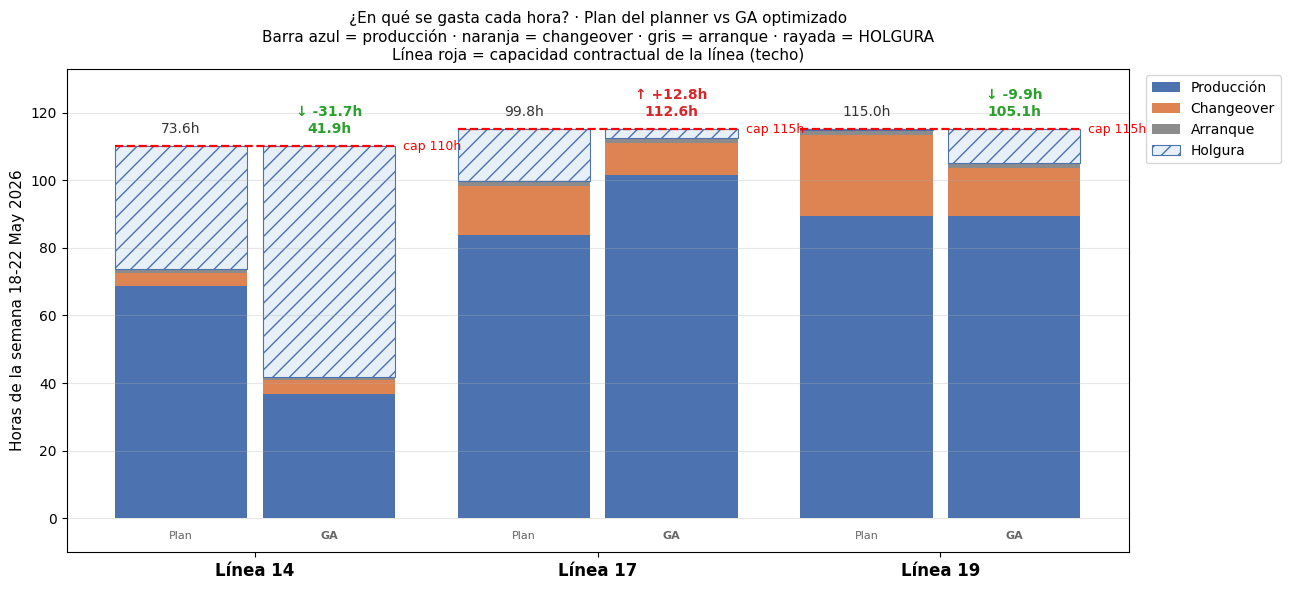

In [57]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

LINE_COLOR = {"14": "#1f77b4", "17": "#ff7f0e", "19": "#2ca02c"}

# 1. Stacked bars — where every hour goes
fig, ax = plt.subplots(figsize=(13, 6))
n_lines = len(LINES)
group_centers = np.arange(n_lines) * 2.2
width = 0.85
offset_b = -width/2 - 0.05
offset_o = +width/2 + 0.05

def _stack(bd, offset, tag):
    prod = np.array([bd[l]["prod"] for l in LINES])
    co = np.array([bd[l]["changeover"] for l in LINES])
    st = np.array([bd[l]["startup"] for l in LINES])
    total = prod + co + st
    slack = np.array([HOURS_PER_WEEK[l] for l in LINES]) - total
    pos = group_centers + offset
    show_label = (tag == "Baseline")
    ax.bar(pos, prod, width, color="#4c72b0",
           label="Producción" if show_label else None)
    ax.bar(pos, co, width, bottom=prod, color="#dd8452",
           label="Changeover" if show_label else None)
    ax.bar(pos, st, width, bottom=prod + co, color="#8c8c8c",
           label="Arranque" if show_label else None)
    ax.bar(pos, slack, width, bottom=prod + co + st, color="#e7f0f9",
           edgecolor="#4c72b0", hatch="//", linewidth=0.8,
           label="Holgura" if show_label else None)
    return pos, total

pos_b, tot_b = _stack(base_bd, offset_b, "Baseline")
pos_o, tot_o = _stack(opt_bd,  offset_o, "Optimizado")

# Totals + delta annotation per group
for i, l in enumerate(LINES):
    cap = HOURS_PER_WEEK[l]
    # Bar-total labels (placed above the bar, never on it)
    ax.text(pos_b[i], cap + 4, f"{tot_b[i]:.1f}h",
            ha="center", fontsize=10, color="#333")
    delta = tot_o[i] - tot_b[i]
    color = "#2ca02c" if delta < 0 else "#d62728"
    sign = "" if delta == 0 else ("↓" if delta < 0 else "↑")
    ax.text(pos_o[i], cap + 4, f"{tot_o[i]:.1f}h",
            ha="center", fontsize=10, fontweight="bold", color=color)
    ax.text(pos_o[i], cap + 9, f"{sign} {delta:+.1f}h",
            ha="center", fontsize=10, fontweight="bold", color=color)
    # Capacity ceiling (red dashed)
    ax.hlines(cap, pos_b[i] - width/2, pos_o[i] + width/2,
              color="red", linestyles="--", linewidth=1.6)
    ax.text(pos_o[i] + width/2 + 0.05, cap, f"cap {cap:.0f}h",
            color="red", fontsize=9, va="center", ha="left")
    # Sub-axis labels: which is which
    ax.text(pos_b[i], -6, "Plan", ha="center", fontsize=8, color="#666")
    ax.text(pos_o[i], -6, "GA",   ha="center", fontsize=8, color="#666", fontweight="bold")

ax.set_xticks(group_centers)
ax.set_xticklabels([f"Línea {l}" for l in LINES], fontsize=12, fontweight="bold")
ax.set_ylabel("Horas de la semana 18-22 May 2026", fontsize=11)
ax.set_title("¿En qué se gasta cada hora? · Plan del planner vs GA optimizado\n"
             "Barra azul = producción · naranja = changeover · gris = arranque · rayada = HOLGURA\n"
             "Línea roja = capacidad contractual de la línea (techo)",
             fontsize=11)
ax.set_ylim(-10, max(HOURS_PER_WEEK.values()) + 18)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=10, frameon=True)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [58]:

def _gantt(ax, individual, breakdown_dict, title):
    fmt_color = {"1/2": "#4c72b0", "1/3": "#dd8452", "2/5": "#55a868"}
    y_pos = {line: i for i, line in enumerate(LINES)}
    for line in LINES:
        cursor = STARTUP_HOURS[line]
        # Startup block
        ax.broken_barh([(0, STARTUP_HOURS[line])], (y_pos[line] - 0.35, 0.7),
                       facecolors="#bdbdbd", edgecolors="black", linewidth=0.4)
        ax.text(STARTUP_HOURS[line] / 2, y_pos[line], "ARR",
                ha="center", va="center", fontsize=6, color="black")
        prev = None
        for sku in individual[line]:
            if prev is not None:
                co = changeover_hours(prev, sku, line)
                if co > 0:
                    ax.broken_barh([(cursor, co)], (y_pos[line] - 0.35, 0.7),
                                   facecolors="#d62728", edgecolors="black", linewidth=0.4, alpha=0.7)
                    cursor += co
            prod_h = VOLUMES[sku] / throughput(sku, line)
            color = fmt_color.get(SKU_FORMAT.get(sku), "#999999")
            ax.broken_barh([(cursor, prod_h)], (y_pos[line] - 0.35, 0.7),
                           facecolors=color, edgecolors="black", linewidth=0.4)
            if prod_h >= 2.5:
                ax.text(cursor + prod_h / 2, y_pos[line], sku,
                        ha="center", va="center", fontsize=6.5, color="white")
            cursor += prod_h
            prev = sku
        # Capacity marker
        ax.axvline(HOURS_PER_WEEK[line], color="red", ls="--", lw=0.8, alpha=0.6)
    ax.set_yticks(list(y_pos.values()))
    ax.set_yticklabels([f"L{line}\n{breakdown_dict[line]['total']:.1f}h"
                        for line in LINES])
    ax.set_xlabel("Horas desde inicio de semana")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    handles = [mpatches.Patch(color=fmt_color["1/2"], label="50cl"),
               mpatches.Patch(color=fmt_color["1/3"], label="33cl"),
               mpatches.Patch(color=fmt_color["2/5"], label="44cl"),
               mpatches.Patch(color="#d62728", label="Changeover", alpha=0.7),
               mpatches.Patch(color="#bdbdbd", label="Arranque")]
    ax.legend(handles=handles, loc="lower right", fontsize=7)


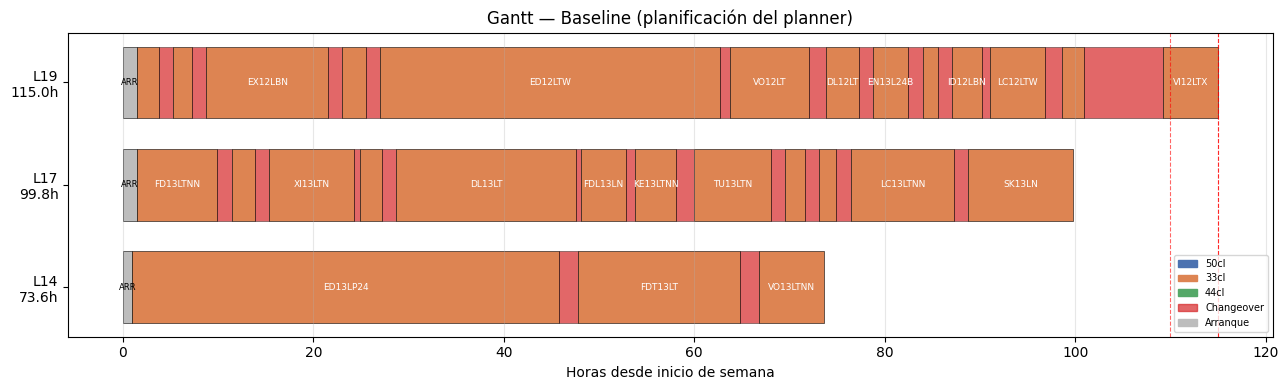

In [59]:

fig, ax = plt.subplots(figsize=(13, 4))
_gantt(ax, base_ind, base_bd, "Gantt — Baseline (planificación del planner)")
plt.tight_layout(); plt.show()


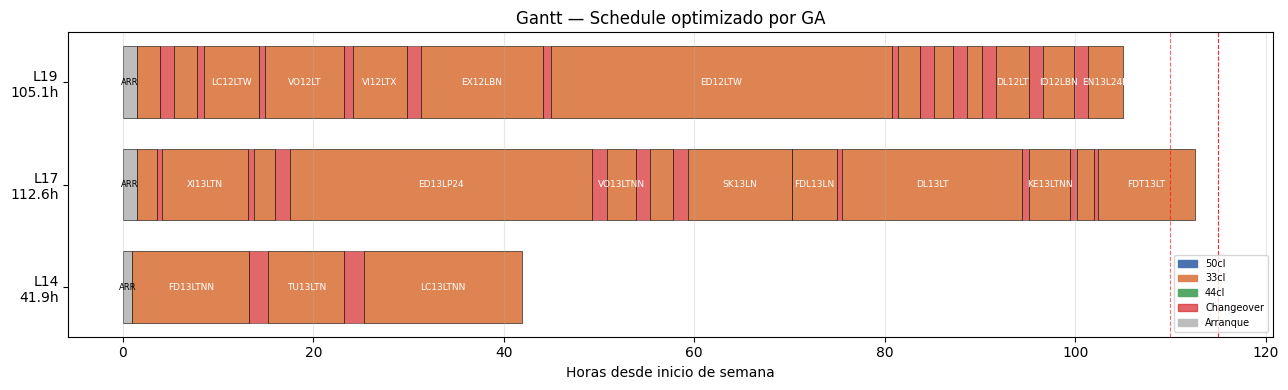

In [60]:

fig, ax = plt.subplots(figsize=(13, 4))
_gantt(ax, best_ind, opt_bd, "Gantt — Schedule optimizado por GA")
plt.tight_layout(); plt.show()


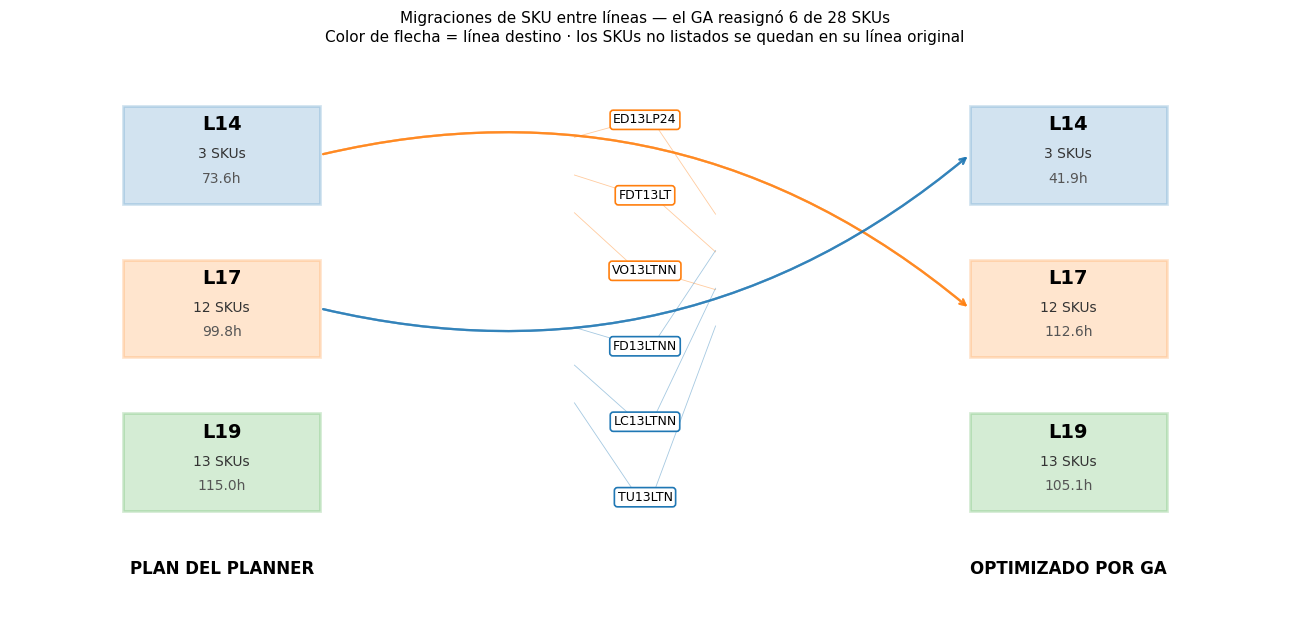

In [61]:

# SKU migrations: which SKUs the GA moved between lines
base_line_of = {sku: line for line in LINES for sku in base_ind[line]}
opt_line_of  = {sku: line for line in LINES for sku in best_ind[line]}
migrations = [(sku, base_line_of[sku], opt_line_of[sku])
              for sku in SKUS if base_line_of[sku] != opt_line_of[sku]]

fig, ax = plt.subplots(figsize=(13, 6.5))
LEFT, RIGHT = 0.0, 6.0
BOX_W, BOX_H = 1.4, 1.4
LINE_Y = {line: i * 2.2 for i, line in enumerate(reversed(LINES))}
# (reversed so L14 appears at the bottom and L19 at the top, like a Gantt)

def _box(x, line, side_label):
    y = LINE_Y[line]
    ax.add_patch(plt.Rectangle((x - BOX_W/2, y - BOX_H/2), BOX_W, BOX_H,
                                facecolor=LINE_COLOR[line], alpha=0.20,
                                edgecolor=LINE_COLOR[line], linewidth=2))
    n_b = len(base_ind[line])
    n_o = len(best_ind[line])
    n_now = n_b if side_label == "BASELINE" else n_o
    h_now = base_bd[line]["total"] if side_label == "BASELINE" else opt_bd[line]["total"]
    ax.text(x, y + 0.35, f"L{line}", ha="center", fontsize=14, fontweight="bold")
    ax.text(x, y - 0.05, f"{n_now} SKUs", ha="center", fontsize=10, color="#333")
    ax.text(x, y - 0.4, f"{h_now:.1f}h", ha="center", fontsize=10, color="#555")

for line in LINES:
    _box(LEFT, line, "BASELINE")
    _box(RIGHT, line, "OPTIMIZADO")

ax.text(LEFT, -1.6, "PLAN DEL PLANNER", ha="center", fontsize=12, fontweight="bold")
ax.text(RIGHT, -1.6, "OPTIMIZADO POR GA", ha="center", fontsize=12, fontweight="bold")

# Sort migrations so vertical placement is deterministic, then assign each a
# distinct y track along the middle gap to keep labels readable.
migrations_sorted = sorted(migrations, key=lambda x: (LINES.index(x[1]), LINES.index(x[2])))
n_mig = len(migrations_sorted)
mid_x = (LEFT + RIGHT) / 2
gap_top = max(LINE_Y.values()) + 0.5
gap_bot = min(LINE_Y.values()) - 0.5
track_ys = np.linspace(gap_top, gap_bot, n_mig) if n_mig > 1 else [(gap_top + gap_bot) / 2]

for (sku, src, dst), label_y in zip(migrations_sorted, track_ys):
    src_y = LINE_Y[src]
    dst_y = LINE_Y[dst]
    # Curved arrow from src box to dst box
    ax.annotate("",
                xy=(RIGHT - BOX_W/2, dst_y),
                xytext=(LEFT + BOX_W/2, src_y),
                arrowprops=dict(arrowstyle="->", lw=1.6, alpha=0.55,
                                color=LINE_COLOR[dst],
                                connectionstyle=f"arc3,rad={0.25 if dst_y > src_y else -0.25 if dst_y < src_y else 0}"))
    # Label box on its own track
    ax.text(mid_x, label_y, sku, fontsize=9, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.25", fc="white",
                      ec=LINE_COLOR[dst], lw=1.2))
    # small connector from label to src and dst y-levels via slight tick marks
    ax.plot([mid_x - 0.05, mid_x - 0.5], [label_y, (label_y + src_y) / 2],
            color=LINE_COLOR[dst], lw=0.6, alpha=0.4)
    ax.plot([mid_x + 0.05, mid_x + 0.5], [label_y, (label_y + dst_y) / 2],
            color=LINE_COLOR[dst], lw=0.6, alpha=0.4)

ax.set_xlim(-1.5, 7.5)
ax.set_ylim(-2.4, max(LINE_Y.values()) + 1.5)
ax.axis("off")
ax.set_title(f"Migraciones de SKU entre líneas — el GA reasignó {n_mig} de {len(SKUS)} SKUs\n"
             "Color de flecha = línea destino · los SKUs no listados se quedan en su línea original",
             fontsize=11)
plt.tight_layout()
plt.show()


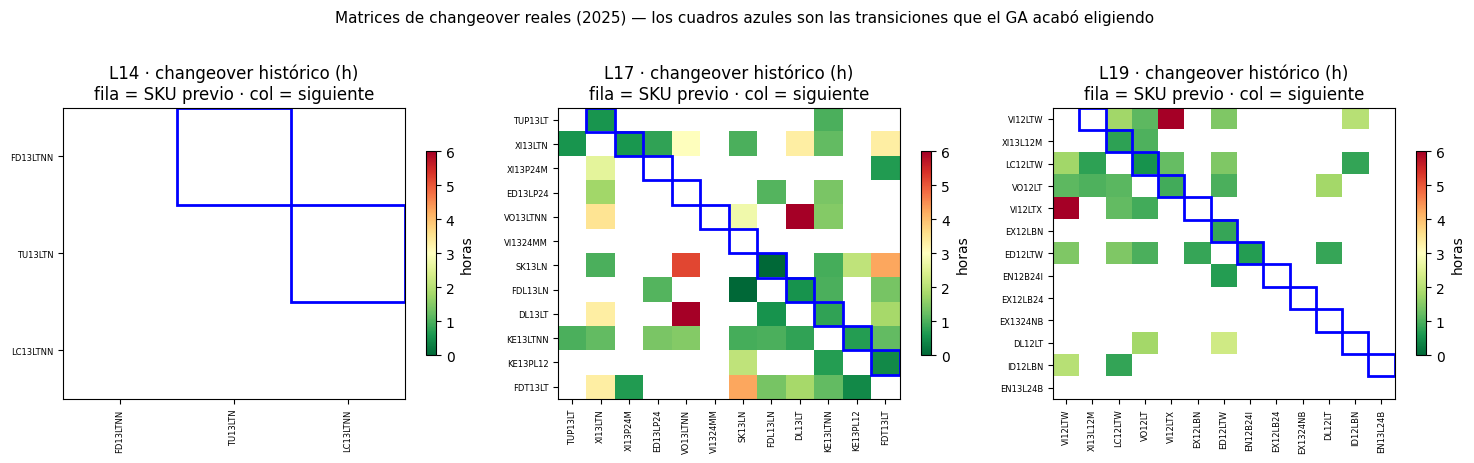

In [62]:

# Heatmap of real changeover matrix per line — restricted to SKUs of this week
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, line in zip(axes, LINES):
    skus_week = [s for s in best_ind[line]]
    mat = np.full((len(skus_week), len(skus_week)), np.nan)
    for i, p in enumerate(skus_week):
        for j, n in enumerate(skus_week):
            if i == j:
                continue
            val = CHANGEOVER[line].get((p, n))
            if val is None:
                val = CHANGEOVER[line].get((n, p))
            mat[i, j] = val if val is not None else np.nan
    im = ax.imshow(mat, cmap="RdYlGn_r", vmin=0, vmax=6, aspect="auto")
    ax.set_xticks(range(len(skus_week)))
    ax.set_yticks(range(len(skus_week)))
    ax.set_xticklabels(skus_week, rotation=90, fontsize=6)
    ax.set_yticklabels(skus_week, fontsize=6)
    ax.set_title(f"L{line} · changeover histórico (h)\nfila = SKU previo · col = siguiente")
    # Mark the actual sequence path used by the GA
    for i in range(len(skus_week) - 1):
        ax.add_patch(plt.Rectangle((i + 1 - 0.5, i - 0.5), 1, 1,
                                    fill=False, edgecolor="blue", linewidth=2))
    plt.colorbar(im, ax=ax, shrink=0.7, label="horas")
fig.suptitle("Matrices de changeover reales (2025) — los cuadros azules son las transiciones "
             "que el GA acabó eligiendo", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


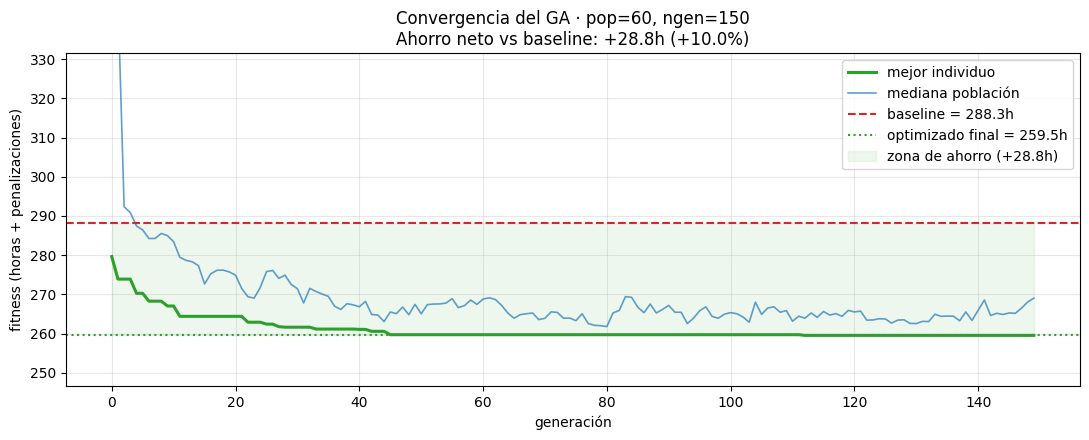

In [63]:

# Convergence with baseline reference line
hist_df = pd.DataFrame(history)
baseline_total = sum(base_bd[l]["total"] for l in LINES)
opt_total = sum(opt_bd[l]["total"] for l in LINES)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(hist_df["gen"], hist_df["best"], label="mejor individuo", color="#2ca02c", lw=2.2)
ax.plot(hist_df["gen"], hist_df["median"], label="mediana población",
        color="#1f77b4", lw=1.2, alpha=0.7)
ax.axhline(baseline_total, color="#d62728", ls="--", lw=1.5,
           label=f"baseline = {baseline_total:.1f}h")
ax.axhline(opt_total, color="#2ca02c", ls=":", lw=1.5,
           label=f"optimizado final = {opt_total:.1f}h")
ax.fill_between(hist_df["gen"], opt_total, baseline_total,
                color="#2ca02c", alpha=0.08,
                label=f"zona de ahorro ({baseline_total - opt_total:+.1f}h)")
ax.set_xlabel("generación")
ax.set_ylabel("fitness (horas + penalizaciones)")
ax.set_title(f"Convergencia del GA · pop={POP_SIZE}, ngen={N_GEN}\n"
             f"Ahorro neto vs baseline: {baseline_total - opt_total:+.1f}h "
             f"({(baseline_total - opt_total) / baseline_total * 100:+.1f}%)")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
# Trim y-axis to ignore early penalty spikes
ax.set_ylim(min(hist_df["best"].min(), opt_total) * 0.95,
            baseline_total * 1.15)
plt.tight_layout()
plt.show()


In [64]:
# Export business handoff: ROI table + Gantt + assignment dict
director_view = {
    "week": "18-22 May 2026",
    "roi_table": roi.to_dict("records"),
    "schedule": {line: best_ind[line] for line in LINES},
    "breakdown": {line: opt_bd[line] for line in LINES},
    "gantt_rows": gantt.to_dict("records"),
    "savings": {
        "total_hours_saved": round(total_b - total_o, 2),
        "baseline_total_h": round(total_b, 2),
        "optimized_total_h": round(total_o, 2),
        "l19_baseline_h": round(base_bd['19']['total'], 2),
        "l19_optimized_h": round(opt_bd['19']['total'], 2),
    },
}
out_path = Path("/tmp/director_view.json")
out_path.write_text(json.dumps(director_view, default=str, indent=2))
print(f"Director view written to {out_path}")


Director view written to /tmp/director_view.json


---

### Mentor-rule traceability

| Rule | Implemented in |
|---|---|
| Minimise hours == maximise OEE | `evaluate_schedule()` returns total hours; GA minimises. |
| L14: 1/2 + 1/3 · L17: 1/3 · L19: 1/2 + 1/3 + 2/5 | `PHYSICAL_FORMAT_BY_LINE` + `ELIGIBLE` filter at `smart_init()` and `crossover()`. |
| Historical 2025 precedent only | `hist_pairs` set + death penalty in `evaluate_schedule()`. |
| Hard caps 110 / 115 / 115 h | `HOURS_PER_WEEK` + **exponential** capacity penalty. |
| Urgent SKU `VI1324MY` → first 25 % of L17 | `PRIORITY_ORDERS` + `smart_init()` pre-places it + linear penalty if displaced. |
| Real changeover times | Lookup `CHANGEOVER[line][(prev, next)]` from `PostMortemAnalysis.build_transition_matrices()`. |
| Bottleneck balancing | `mutate_migrate()` explicitly off-loads the most-overloaded line to compatible underloaded ones. |
